# Car Price Prediction
### Predicting the ex-showroom price of cars using their specifications (2021 dataset)


## Question

Can we guess the price of a car just by looking at its specifications, like engine power, mileage, size, seats, and fuel type? That is what I am trying to find out in this project.


## Aim / Objectives

- Clean the raw car dataset so it is usable (it has missing values and messy text like "1998 cc").
- Fill in missing values properly instead of just dropping rows.
- Find and fix outliers (cars with weird/extreme values that can confuse the model).
- Check which specs are related to price the most, using a correlation heatmap.
- Train a model (Random Forest) that can predict a car's price from its specs.
- Check how good the model is using MAE, RMSE, MAPE and R².
- Compare it with a simple Linear Regression model to see if the extra complexity is actually worth it.


## Methodology

Here is the step by step process I followed:

1. **Load the data** – read the CSV file with all the car details.
2. **Clean it up** – drop columns that had too many missing values, keep only the columns I actually need, and remove junk text from numbers (like removing "mm", "cc", "kg", "litres" from values so they become proper numbers).
3. **Fill missing values** – for number columns I used the median, for category columns I used the mode (the most common value).
4. **Convert text to numbers** – things like fuel type or brake type were turned into numbers so the model can understand them. Columns with multiple categories (like Body Type) were one-hot encoded.
5. **Find and fix outliers** – plotted boxplots and histograms to see which columns had extreme values, used the IQR method to count them, and capped the extreme values instead of deleting the rows.
6. **Check correlations** – made a heatmap to see which specs are most linked to price.
7. **Build the model** – split the data into train (80%) and test (20%), then trained a Random Forest Regressor on it.
8. **Build a baseline** – also trained a plain Linear Regression model on the same data, so I have something to compare against.
9. **Check the results** – used MAE, RMSE, MAPE and R² to see how close the predictions were to the real prices, and made some graphs to visualize it.


## Python Code


### Step 1: Import the libraries I need


In [21]:
!pip install pandas
import pandas as pd
!pip install numpy
import numpy as np
!pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")


### Step 2: Load the dataset


In [22]:
# Load the Dataset
from pathlib import Path

DATA_PATH = Path.cwd() / "cars_ds_final_2021.csv"
if not DATA_PATH.exists():
    DATA_PATH = Path(__file__).resolve().parent / "cars_ds_final_2021.csv"

df = pd.read_csv(DATA_PATH)
df

,Unnamed: 0,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
0,0,Tata,Nano Genx,Xt,"Rs. 2,92,667",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Tata,Nano Genx,Xe,"Rs. 2,36,447",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Tata,Nano Genx,Emax Xm,"Rs. 2,96,661",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Tata,Nano Genx,Xta,"Rs. 3,34,768",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Tata,Nano Genx,Xm,"Rs. 2,72,223",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,1262,Bmw,X5,Xdrive30D Xline,"Rs. 82,90,000",2993 cc,6.0,4.0,AWD (All Wheel Drive),In-line,...,Yes,Yes,NaN,Yes,Yes,NaN,Yes,Yes,NaN,NaN
1263,1263,Bmw,X5,Xdrive40I M Sport,"Rs. 82,90,000",2998 cc,6.0,4.0,AWD (All Wheel Drive),In-line,...,Yes,Yes,NaN,Yes,Yes,NaN,NaN,NaN,NaN,NaN
1264,1264,Mahindra,Alturas G4,2Wd At,"Rs. 27,70,150",2157 cc,4.0,NaN,FWD (Front Wheel Drive),In-line,...,Yes,Yes,NaN,Yes,Yes,NaN,NaN,NaN,NaN,NaN
1265,1265,Mahindra,Alturas G4,4Wd At,"Rs. 30,70,150",2157 cc,4.0,4.0,4WD,In-line,...,Yes,Yes,NaN,Yes,Yes,NaN,NaN,NaN,NaN,NaN


### Step 3: Take a first look at the data


In [23]:
#checking the shape
df.shape


(1267, 141)

In [24]:
#initial inspection
df.head()
df.columns
df.info()
df.describe()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Columns: 141 entries, Unnamed: 0 to Electric_Range
dtypes: float64(9), int64(1), str(131)
memory usage: 2.4 MB


,Unnamed: 0,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
count,1267.000000,1192,1267,1267,1267,1255,1201.000000,1165.000000,1260,1254,...,578,494,34,434,540,25.000000,51,69,13,17
unique,NaN,39,263,1048,1162,129,NaN,NaN,4,4,...,1,1,11,1,1,NaN,1,1,5,8
top,NaN,Maruti Suzuki,Nexon,Lxi,"Rs. 9,99,900",1197 cc,NaN,NaN,FWD (Front Wheel Drive),In-line,...,Yes,Yes,"Revotron 1.2 L, BS6 Engine",Yes,Yes,NaN,Yes,Yes,"21.5 kWh,Battery Placed Under Rear Seats",110 km/full charge
freq,NaN,149,24,9,14,106,NaN,NaN,878,1068,...,578,494,6,434,540,NaN,51,69,3,5
mean,633.000000,NaN,NaN,NaN,NaN,NaN,4.382182,3.977682,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.920000,NaN,NaN,NaN,NaN
std,365.895705,NaN,NaN,NaN,NaN,NaN,1.667728,0.836978,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.759386,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,316.500000,NaN,NaN,NaN,NaN,NaN,4.000000,4.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
50%,633.000000,NaN,NaN,NaN,NaN,NaN,4.000000,4.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN
75%,949.500000,NaN,NaN,NaN,NaN,NaN,4.000000,4.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN


### Step 4: Check missing values and pick the columns I actually need


In [25]:
#CHECKING for missing values
df.isnull().sum()
(df.isnull().sum()/len(df))*100
df.isnull().sum().sort_values(ascending= False).head(20)



Front_Tyre_&_Rim                         1267
Rear_Tyre_&_Rim                          1267
Wheels_Size                              1267
Other_Specs                              1257
Recommended_Tyre_Pressure                1257
Battery                                  1254
Electric_Range                           1250
USB_Ports                                1242
ARAI_Certified_Mileage_for_CNG           1240
Engine_Type                              1233
3_Point_Seat-Belt_in_Middle_Rear_Seat    1216
Heads-Up_Display                         1216
Ambient_Lightning                        1211
Other_specs                              1205
Lane_Watch_Camera/_Side_Mirror_Camera    1201
Welcome_Lights                           1198
Walk_Away_Auto_Car_Lock                  1164
Cargo/Boot_Lights                        1146
Voice_Recognition                        1135
Apple_CarPlay                            1103
dtype: int64

In [26]:
#keeping colums with >=20%
df = df.dropna(axis=1,thresh=0.2*len(df))
df

,Unnamed: 0,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,...,Cooled_Glove_Box,Heated_Seats,Turbocharger,ISOFIX_(Child-Seat_Mount),Rain_Sensing_Wipers,Paddle_Shifters,Leather_Wrapped_Steering,Automatic_Headlamps,ASR_/_Traction_Control,Cruise_Control
0,0,Tata,Nano Genx,Xt,"Rs. 2,92,667",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Tata,Nano Genx,Xe,"Rs. 2,36,447",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Tata,Nano Genx,Emax Xm,"Rs. 2,96,661",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Tata,Nano Genx,Xta,"Rs. 3,34,768",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Tata,Nano Genx,Xm,"Rs. 2,72,223",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,1262,Bmw,X5,Xdrive30D Xline,"Rs. 82,90,000",2993 cc,6.0,4.0,AWD (All Wheel Drive),In-line,...,Yes,NaN,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1263,1263,Bmw,X5,Xdrive40I M Sport,"Rs. 82,90,000",2998 cc,6.0,4.0,AWD (All Wheel Drive),In-line,...,Yes,NaN,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1264,1264,Mahindra,Alturas G4,2Wd At,"Rs. 27,70,150",2157 cc,4.0,NaN,FWD (Front Wheel Drive),In-line,...,Yes,NaN,Yes,Yes,NaN,Yes,Yes,Yes,Yes,Yes
1265,1265,Mahindra,Alturas G4,4Wd At,"Rs. 30,70,150",2157 cc,4.0,4.0,4WD,In-line,...,Yes,Only front,Yes,Yes,Yes,NaN,Yes,Yes,Yes,Yes


In [27]:
required_columns = [
    "Make", "Model", "Variant", "Ex-Showroom_Price", "Displacement", "Cylinders",
    "Fuel_Tank_Capacity", "Fuel_Type", "Height", "Length", "Width", "Body_Type",
    "Doors", "ARAI_Certified_Mileage", "Kerb_Weight", "Gears", "Ground_Clearance",
    "Front_Brakes", "Rear_Brakes", "Power", "Torque", "Seating_Capacity", "Type",
    "Start_/_Stop_Button", "Airbags", "Fasten_Seat_Belt_Warning", "Gear_Shift_Reminder"
]


In [28]:
df = df[required_columns]
df.head(20)

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Fuel_Tank_Capacity,Fuel_Type,Height,Length,...,Front_Brakes,Rear_Brakes,Power,Torque,Seating_Capacity,Type,Start_/_Stop_Button,Airbags,Fasten_Seat_Belt_Warning,Gear_Shift_Reminder
0,Tata,Nano Genx,Xt,"Rs. 2,92,667",624 cc,2.0,24 litres,Petrol,1652 mm,3164 mm,...,Drum,Drum,38PS@5500rpm,51Nm@4000rpm,4.0,Manual,Yes,NaN,NaN,NaN
1,Tata,Nano Genx,Xe,"Rs. 2,36,447",624 cc,2.0,24 litres,Petrol,1652 mm,3164 mm,...,Drum,Drum,38PS@5500rpm,51Nm@4000rpm,4.0,Manual,NaN,NaN,NaN,NaN
2,Tata,Nano Genx,Emax Xm,"Rs. 2,96,661",624 cc,2.0,15 litres,CNG,1652 mm,3164 mm,...,Drum,Drum,38PS@5500rpm,51Nm@4000rpm,4.0,Manual,NaN,NaN,NaN,NaN
3,Tata,Nano Genx,Xta,"Rs. 3,34,768",624 cc,2.0,24 litres,Petrol,1652 mm,3164 mm,...,Drum,Drum,38PS@5500rpm,51Nm@4000rpm,4.0,Automatic,Yes,NaN,NaN,NaN
4,Tata,Nano Genx,Xm,"Rs. 2,72,223",624 cc,2.0,24 litres,Petrol,1652 mm,3164 mm,...,Drum,Drum,38PS@5500rpm,51Nm@4000rpm,4.0,Manual,NaN,NaN,NaN,NaN
5,Tata,Nano Genx,Xma,"Rs. 3,14,815",624 cc,2.0,24 litres,Petrol,1652 mm,3164 mm,...,Drum,Drum,38PS@5500rpm,51Nm@4000rpm,4.0,Automatic,NaN,NaN,NaN,NaN
6,Datsun,Redi-Go,D,"Rs. 2,79,650",799 cc,3.0,28 litres,Petrol,1541 mm,3429 mm,...,Ventilated Disc,Drum,54PS@5678rpm,72Nm@4386rpm,5.0,Manual,NaN,NaN,NaN,NaN
7,Datsun,Redi-Go,T,"Rs. 3,51,832",799 cc,3.0,28 litres,Petrol,1541 mm,3429 mm,...,Ventilated Disc,Drum,54PS@5678rpm,72Nm@4386rpm,5.0,Manual,NaN,NaN,NaN,NaN
8,Datsun,Redi-Go,A,"Rs. 3,33,419",799 cc,3.0,28 litres,Petrol,1541 mm,3429 mm,...,Ventilated Disc,Drum,54PS@5678rpm,72Nm@4386rpm,5.0,Manual,NaN,NaN,NaN,NaN
9,Datsun,Redi-Go,S,"Rs. 3,62,000",799 cc,3.0,28 litres,Petrol,1541 mm,3429 mm,...,Ventilated Disc,Drum,54PS@5678rpm,72Nm@4386rpm,5.0,Manual,NaN,NaN,NaN,NaN


### Step 5: Clean up the columns

This is the biggest part. I fix the units (remove things like "mm", "cc", "kg"), fix the data types, fill in missing values (median for number columns, mode for category columns), and turn categories into numbers so the model can use them.


In [29]:
#impute numerical value
df["Cylinders"] = df["Cylinders"].fillna(df["Cylinders"].median())
df["Cylinders"]
df["Cylinders"] = df["Cylinders"].astype(int)

In [30]:
# Doors and Gears were never actually cleaned anywhere in the original notebook, so they still had missing values -- this is what was causing LinearRegression to crash with a NaN error.

# Doors: pull out just the number, then fill any missing ones with the median
df["Doors"] = df["Doors"].astype(str).str.extract(r"(\d+)")
df["Doors"] = pd.to_numeric(df["Doors"], errors="coerce")
df["Doors"] = df["Doors"].fillna(df["Doors"].median())
df["Doors"] = df["Doors"].astype(int)


In [31]:
# Gears: same idea -- extract the number, fill missing values with the median
df["Gears"] = df["Gears"].astype(str).str.extract(r"(\d+)")
df["Gears"] = pd.to_numeric(df["Gears"], errors="coerce")
df["Gears"] = df["Gears"].fillna(df["Gears"].median())
df["Gears"] = df["Gears"].astype(int)


In [32]:
#fix data type convert to integer
 # Step 1: Remove "Rs." and commas
df['Ex-Showroom_Price'] = df['Ex-Showroom_Price'].str.replace("Rs.", "", regex=False)
df['Ex-Showroom_Price'] = df['Ex-Showroom_Price'].str.replace(",", "", regex=False)

# Step 2: Convert to numeric
df['Ex-Showroom_Price'] = pd.to_numeric(df['Ex-Showroom_Price'], errors='coerce')

# Step 3: Verify
print(df['Ex-Showroom_Price'].head())
print(df['Ex-Showroom_Price'].dtype)



0    292667
1    236447
2    296661
3    334768
4    272223
Name: Ex-Showroom_Price, dtype: int64
int64


In [33]:
df.columns.tolist()

['Make',
 'Model',
 'Variant',
 'Ex-Showroom_Price',
 'Displacement',
 'Cylinders',
 'Fuel_Tank_Capacity',
 'Fuel_Type',
 'Height',
 'Length',
 'Width',
 'Body_Type',
 'Doors',
 'ARAI_Certified_Mileage',
 'Kerb_Weight',
 'Gears',
 'Ground_Clearance',
 'Front_Brakes',
 'Rear_Brakes',
 'Power',
 'Torque',
 'Seating_Capacity',
 'Type',
 'Start_/_Stop_Button',
 'Airbags',
 'Fasten_Seat_Belt_Warning',
 'Gear_Shift_Reminder']

In [34]:
# Step 1: Remove "cc" and force to string
df["Displacement"] = df["Displacement"].astype(str).str.replace("cc", "", regex=False)

# Step 2: Convert to numeric
df["Displacement"] = pd.to_numeric(df["Displacement"], errors="coerce")

# Step 3: Fill missing values with median
median_value = df["Displacement"].median()
df["Displacement"] = df["Displacement"].fillna(median_value)

# Step 4: Convert to integer
df["Displacement"] = df["Displacement"].astype(int)




In [35]:
print(df["Displacement"].head())
print(df["Displacement"].dtype)

0    624
1    624
2    624
3    624
4    624
Name: Displacement, dtype: int64
int64


In [36]:
# Step 1: Remove "litres" and convert to numeric
df["Fuel_Tank_Capacity"] = (
    df["Fuel_Tank_Capacity"].astype(str).str.replace("litres", "", regex=False)
)
df["Fuel_Tank_Capacity"] = pd.to_numeric(df["Fuel_Tank_Capacity"], errors="coerce")

# Step 2: Fill missing values with median
median_valu = df["Fuel_Tank_Capacity"].median()
df["Fuel_Tank_Capacity"] = df["Fuel_Tank_Capacity"].fillna(median_valu)

# Step 3: Convert safely to integer
df["Fuel_Tank_Capacity"] = df["Fuel_Tank_Capacity"].round().astype(int)


In [37]:
print(df["Fuel_Tank_Capacity"].dtype)

int64


In [38]:
print(df["Fuel_Type"].unique())


<ArrowStringArray>
['Petrol', 'CNG', 'Diesel', 'CNG + Petrol', 'Electric', 'Hybrid']
Length: 6, dtype: str


In [39]:
df["Fuel_Type"].isna().any()


np.False_

In [40]:
df["Fuel_Type"] = df["Fuel_Type"].astype(str).str.strip().str.title()


In [41]:
df["Fuel_Type"] = df["Fuel_Type"].replace({
    "Cng": "CNG",
    "Cng + Petrol": "CNG + Petrol"
})


In [42]:
print(df["Fuel_Type"].unique())


<ArrowStringArray>
['Petrol', 'CNG', 'Diesel', 'CNG + Petrol', 'Electric', 'Hybrid']
Length: 6, dtype: str


In [43]:
df["Fuel_Type"] = df["Fuel_Type"].map({
   "Petrol": 1,
    "CNG": 2,
    "Diesel": 3,
    "CNG + Petrol": 4,
    "Electric": 5,
    "Hybrid": 6,
})


In [44]:
print(df["Fuel_Type"].dtype)

int64


In [45]:
print(df["Width"].unique())
print(df["Width"].isna().sum())


<ArrowStringArray>
['1750 mm', '1560 mm', '1579 mm', '1580 mm', '1475 mm', '1490 mm', '1636 mm',
 '1600 mm', '1645 mm', '1677 mm',
 ...
 '1929 mm', '1620 mm', '1675 mm', '1814 mm', '1918 mm', '2153 mm', '1915 mm',
 '2218 mm', '1960 mm', '1971 mm']
Length: 183, dtype: str
12


In [46]:
# Step 1: Remove the unit text (like 'mm')
df["Width"] = df["Width"].astype(str).str.replace("mm", "", regex=False).str.strip()

# Step 2: Convert to numeric
df["Width"] = pd.to_numeric(df["Width"], errors="coerce")

# Step 3: Fill missing values with median
median_width = df["Width"].median(skipna=True)
df["Width"] = df["Width"].fillna(median_width)

# Step 4: Convert safely to integer
df["Width"] = df["Width"].round().astype(int)


In [47]:
print(df["Body_Type"].unique())

<ArrowStringArray>
[          'Hatchback',                 'MPV',                 'MUV',
                 'SUV',               'Sedan',           'Crossover',
      'Crossover, SUV',      'SUV, Crossover',               'Coupe',
    'Sedan, Crossover',         'Convertible',                   nan,
        'Sedan, Coupe',              'Sports',   'Sports, Hatchback',
 'Sports, Convertible',             'Pick-up',  'Coupe, Convertible']
Length: 18, dtype: str


In [48]:

# Step 1: Normalize text and replace NaN with empty string
df["Body_Type"] = df["Body_Type"].replace(np.nan, "").astype(str).str.strip().str.title()

# Step 2: Create dummy columns for each unique body type
body_dummies = df["Body_Type"].str.get_dummies(sep=",")

# Step 3: Merge back into the main dataframe
df = pd.concat([df, body_dummies], axis=1)


In [49]:
# Step 1: Remove unit text
df["ARAI_Certified_Mileage"] = (
    df["ARAI_Certified_Mileage"]
    .astype(str)
    .str.replace("km/litre", "", regex=False)
    .str.replace("kmpl", "", regex=False)   # handle kmpl too
    .str.strip()
)

# Step 2: Convert to numeric
df["ARAI_Certified_Mileage"] = pd.to_numeric(df["ARAI_Certified_Mileage"], errors="coerce")

# Step 3: Fill missing values with median
median_mileage = df["ARAI_Certified_Mileage"].median(skipna=True)
df["ARAI_Certified_Mileage"] = df["ARAI_Certified_Mileage"].fillna(median_mileage)

# Step 4: Keep as float (recommended, since mileage can be decimal)
df["ARAI_Certified_Mileage"] = df["ARAI_Certified_Mileage"].astype(float)


In [50]:
# Step 1: Remove 'kg' and spaces
df["Kerb_Weight"] = df["Kerb_Weight"].astype(str).str.replace("kg", "", regex=False).str.strip()

# Step 2: Handle ranges like "1016-1043"
def process_weight(val):
    val = str(val).strip()
    if not val or val.lower() in {"nan", "none", "?"}:
        return np.nan
    if "-" in val:
        parts = val.split("-")
        nums = []
        for part in parts:
            try:
                nums.append(float(part.strip()))
            except (TypeError, ValueError):
                pass
        return np.mean(nums) if nums else np.nan
    try:
        return float(val)
    except (TypeError, ValueError):
        return np.nan

df["Kerb_Weight"] = df["Kerb_Weight"].apply(process_weight)

# Step 3: Fill missing values with median
median_weight = df["Kerb_Weight"].median(skipna=True)
df["Kerb_Weight"] = df["Kerb_Weight"].fillna(median_weight)

# Step 4: Convert to integer
df["Kerb_Weight"] = df["Kerb_Weight"].round().astype(int)

In [51]:
print(df["Ground_Clearance"].unique())

<ArrowStringArray>
[  '180 mm',   '185 mm',   '184 mm',   '160 mm',   '165 mm',        nan,
   '170 mm',   '182 mm',   '200 mm',   '154 mm',   '163 mm',   '190 mm',
   '174 mm',   '172 mm',   '205 mm',   '195 mm',   '198 mm',   '210 mm',
   '167 mm',   '175 mm',   '164 mm',   '149 mm',   '133 mm',   '220 mm',
   '215 mm',   '225 mm',   '132 mm',   '183 mm',   '188 mm',   '179 mm',
   '136 mm',   '157 mm',   '112 mm',   '155 mm',   '201 mm',   '158 mm',
   '213 mm',   '152 mm',   '124 mm',   '138 mm',   '235 mm',   '218 mm',
   '238 mm', '295.5 mm',   '227 mm',   '113 mm',   '100 mm',   '121 mm',
   '109 mm',   '295 mm',   '110 mm',   '142 mm',   '119 mm',   '130 mm',
   '150 mm',   '209 mm',   '186 mm',   '192 mm',   '146 mm',   '137 mm',
   '128 mm',   '135 mm',   '208 mm',   '206 mm',   '307 mm',   '241 mm',
   '161 mm',   '211 mm',   '212 mm',   '140 mm',   '108 mm',   '498 mm',
   '122 mm',   '125 mm']
Length: 74, dtype: str


In [52]:

# Step 1: Remove unit text (mm)
df["Ground_Clearance"] = (
    df["Ground_Clearance"]
    .astype(str)
    .str.replace("mm", "", regex=False)
    .str.strip()
)

# Step 2: Convert to numeric
df["Ground_Clearance"] = pd.to_numeric(df["Ground_Clearance"], errors="coerce")

# Step 3: Fill missing values with median
median_clearance = df["Ground_Clearance"].median(skipna=True)
df["Ground_Clearance"] = df["Ground_Clearance"].fillna(median_clearance)

# Step 4: Convert to integer (since clearance is usually whole numbers)
df["Ground_Clearance"] = df["Ground_Clearance"].round().astype(int)


In [53]:
df["Height"] = df["Height"].astype(str).str.replace("mm", "", regex=False)


In [54]:
df["Height"] = pd.to_numeric(df["Height"], errors="coerce")
median_height = df["Height"].median()
df["Height"] = df["Height"].fillna(median_height)
df["Height"] = df["Height"].round().astype(int)


In [55]:
df["Length"] = df["Length"].astype(str).str.replace("mm", "", regex=False)


In [56]:
df["Length"] = pd.to_numeric(df["Length"], errors="coerce")


In [57]:
median_length = df["Length"].median()
df["Length"] = df["Length"].fillna(median_length)
df["Length"] = df["Length"].round().astype(int)


In [58]:
print(df["Front_Brakes"].unique()) 

<ArrowStringArray>
['Drum', 'Ventilated Disc', nan, 'Solid Disc']
Length: 4, dtype: str


In [59]:
mode_value = df["Front_Brakes"].mode()[0]
print("Mode:", mode_value)
df["Front_Brakes"] = df["Front_Brakes"].fillna(mode_value)



Mode: Ventilated Disc


In [60]:
df["Front_Brakes"] = df["Front_Brakes"].map({
    "Drum": 1,
    "Solid Disc": 2,
    "Ventilated Disc": 3,
})


In [61]:
print(df["Rear_Brakes"].unique()) 

<ArrowStringArray>
['Drum', nan, 'Ventilated Disc', 'Solid Disc']
Length: 4, dtype: str


In [62]:
df["Rear_Brakes"] = df["Rear_Brakes"].astype(str).str.strip().str.title()
mode_value = df["Rear_Brakes"].mode()[0]
df["Rear_Brakes"] = df["Rear_Brakes"].replace("Nan", np.nan).fillna(mode_value)


In [63]:
df["Rear_Brakes"] = df["Rear_Brakes"].map({
    "Drum": 1,
    "Solid Disc": 2,
    "Ventilated Disc": 3
})


In [64]:
print(df["Power"].unique())



<ArrowStringArray>
[      '38PS@5500rpm',       '54PS@5678rpm',       '68PS@5500rpm',
       '73PS@6000rpm',       '74PS@6000RPM',       '62PS@6000rpm',
       '68PS@6000rpm',       '68PS@6200rpm',       '59PS@6000rpm',
       '68PS@5000rpm',
 ...
     '248bhp@5200rpm',      '262PS@6000rpm',     '505bhp@6000rpm',
      '180PS@4000rpm',      '460PS@7000RPM',      '265HP@4000rpm',
      '340HP@4000rpm',      '178bhp@400rpm',      '178Bhp @ 4000',
 '789 bhp @ 8500 rpm']
Length: 372, dtype: str


In [65]:
# Remove spaces and standardize text
df["Power"] = df["Power"].astype(str).str.strip()

# Extract only the first number before any letters or symbols
df["Power"] = df["Power"].str.extract(r"^(\d+)")



In [66]:
df["Power"] = pd.to_numeric(df["Power"], errors="coerce")


In [67]:
median_power = df["Power"].median()
df["Power"] = df["Power"].fillna(median_power)


In [68]:
df["Torque"] = df["Torque"].astype(str).str.strip()


In [69]:
df["Torque"] = df["Torque"].str.extract(r"^(\d+)")
df["Torque"] = pd.to_numeric(df["Torque"], errors="coerce")


In [70]:
median_torque = df["Torque"].median()
df["Torque"] = df["Torque"].fillna(median_torque)


In [71]:
df["Torque"] = df["Torque"].round().astype(int)


In [72]:
df["Seating_Capacity"] = pd.to_numeric(df["Seating_Capacity"], errors="coerce")


In [73]:
median_seat = df["Seating_Capacity"].median()
df["Seating_Capacity"] = df["Seating_Capacity"].fillna(median_seat)


In [74]:
df["Seating_Capacity"] = df["Seating_Capacity"].round().astype(int)


In [75]:
df.head(20)

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Fuel_Tank_Capacity,Fuel_Type,Height,Length,...,Convertible,Coupe,Crossover,Hatchback,Mpv,Muv,Pick-Up,Sedan,Sports,Suv
0,Tata,Nano Genx,Xt,292667,624,2,24,1,1652,3164,...,0,0,0,1,0,0,0,0,0,0
1,Tata,Nano Genx,Xe,236447,624,2,24,1,1652,3164,...,0,0,0,1,0,0,0,0,0,0
2,Tata,Nano Genx,Emax Xm,296661,624,2,15,2,1652,3164,...,0,0,0,1,0,0,0,0,0,0
3,Tata,Nano Genx,Xta,334768,624,2,24,1,1652,3164,...,0,0,0,1,0,0,0,0,0,0
4,Tata,Nano Genx,Xm,272223,624,2,24,1,1652,3164,...,0,0,0,1,0,0,0,0,0,0
5,Tata,Nano Genx,Xma,314815,624,2,24,1,1652,3164,...,0,0,0,1,0,0,0,0,0,0
6,Datsun,Redi-Go,D,279650,799,3,28,1,1541,3429,...,0,0,0,1,0,0,0,0,0,0
7,Datsun,Redi-Go,T,351832,799,3,28,1,1541,3429,...,0,0,0,1,0,0,0,0,0,0
8,Datsun,Redi-Go,A,333419,799,3,28,1,1541,3429,...,0,0,0,1,0,0,0,0,0,0
9,Datsun,Redi-Go,S,362000,799,3,28,1,1541,3429,...,0,0,0,1,0,0,0,0,0,0


In [76]:


# Step 1: Normalize text
df["Start_/_Stop_Button"] = (
    df["Start_/_Stop_Button"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Step 2: Convert string "nan"/"Nan" back to real NaN
df["Start_/_Stop_Button"] = df["Start_/_Stop_Button"].replace(["Nan", "nan"], np.nan)

# Step 3: Fill missing values with mode
mode_value = df["Start_/_Stop_Button"].mode()[0]
df["Start_/_Stop_Button"] = df["Start_/_Stop_Button"].fillna(mode_value)

# Step 4: Map to numeric codes
df["Start_/_Stop_Button"] = df["Start_/_Stop_Button"].map({
    "Yes": 1,
    "No": 0
})

# Step 5: Convert to integer type
df["Start_/_Stop_Button"] = df["Start_/_Stop_Button"].astype(int)


In [77]:
print(df["Start_/_Stop_Button"].unique())
type(df["Start_/_Stop_Button"].dtype)

[1]


numpy.dtypes.Int64DType

In [78]:
# Normalize text
df["Airbags"] = df["Airbags"].astype(str).str.strip()

# Replace literal "nan" strings with proper NaN
df["Airbags"] = df["Airbags"].replace("nan", np.nan)

# Fill missing with mode 
mode_airbags = df["Airbags"].mode()[0]
df["Airbags"] = df["Airbags"].fillna(mode_airbags)


In [79]:
df["Fasten_Seat_Belt_Warning"] = df["Fasten_Seat_Belt_Warning"].astype(str).str.strip().str.title()


In [80]:
mode_value = df["Fasten_Seat_Belt_Warning"].mode()[0]
df["Fasten_Seat_Belt_Warning"] = df["Fasten_Seat_Belt_Warning"].replace("Nan", np.nan).fillna(mode_value)


In [81]:
df["Fasten_Seat_Belt_Warning"] = df["Fasten_Seat_Belt_Warning"].map({
    "Yes": 1,
    "No": 0
}).fillna(0)


In [82]:
df["Gear_Shift_Reminder"] = df["Gear_Shift_Reminder"].astype(str).str.strip().str.title()


In [83]:
mode_value = df["Gear_Shift_Reminder"].mode()[0]
df["Gear_Shift_Reminder"] = df["Gear_Shift_Reminder"].replace("Nan", np.nan).fillna(mode_value)


In [84]:
df["Gear_Shift_Reminder"] = df["Gear_Shift_Reminder"].map({
    "Yes": 1,
    "No": 0
}).fillna(0)


In [85]:
df["Type"] = df["Type"].astype(str).str.strip().str.title()



In [86]:

mode_type = df["Type"].mode()[0]
df["Type"] = df["Type"].replace("Nan", np.nan).fillna(mode_type)


In [87]:
print(df["Type"].unique())

<ArrowStringArray>
['Manual', 'Automatic', 'Amt', 'Cvt', 'Dct']
Length: 5, dtype: str


In [88]:
df["Type"] = df["Type"].map({
   "Manual": 1,
       "Automatic": 2,
       "Amt": 3,   
       "Cvt": 4,   
       "Dct": 5
}).fillna(0)
        


In [89]:

# Make sure the column is string
df["Airbags"] = df["Airbags"].astype(str)

# Count airbags by splitting on commas
df["Airbags_Count"] = df["Airbags"].apply(
    lambda x: len(x.split(",")) if x.lower() != "nan" else np.nan
)

# Fill missing values with median
df["Airbags_Count"] = df["Airbags_Count"].fillna(df["Airbags_Count"].median()).astype(int)


### Step 6: Find and fix outliers

Before training the model, I want to check the numeric columns for outliers using boxplots and the IQR method. A few extreme values (like a data entry mistake in price or weight) can mess up a regression model pretty badly.


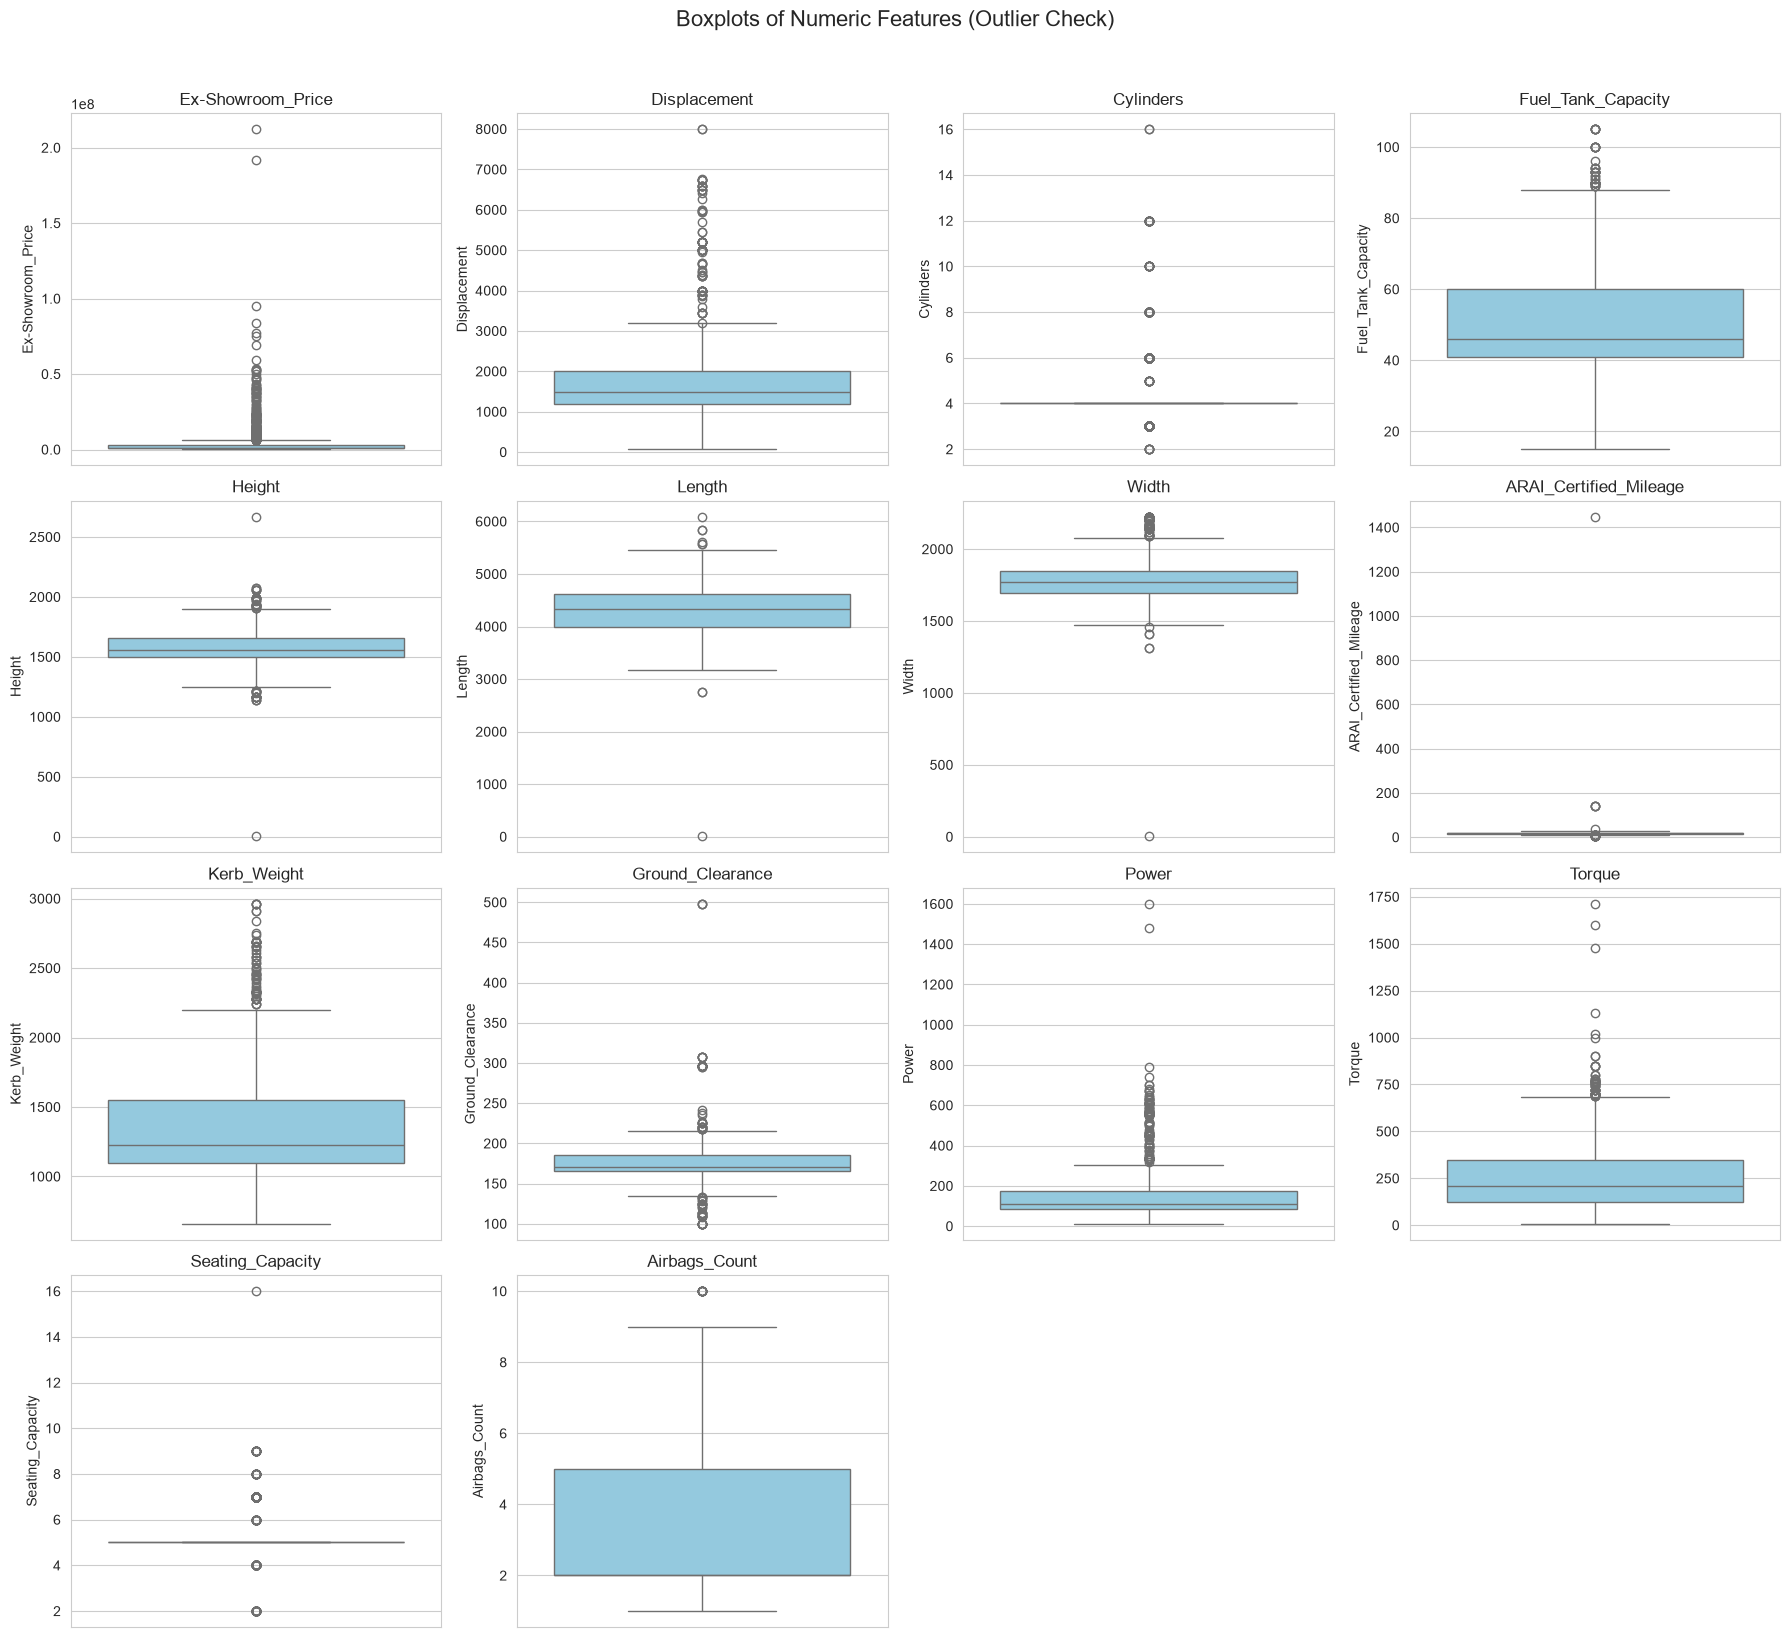

In [90]:
numeric_cols = [
    "Ex-Showroom_Price", "Displacement", "Cylinders", "Fuel_Tank_Capacity",
    "Height", "Length", "Width", "ARAI_Certified_Mileage", "Kerb_Weight",
    "Ground_Clearance", "Power", "Torque", "Seating_Capacity", "Airbags_Count"
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

# Boxplots to visually spot outliers in each numeric column
n_cols = 4
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots of Numeric Features (Outlier Check)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


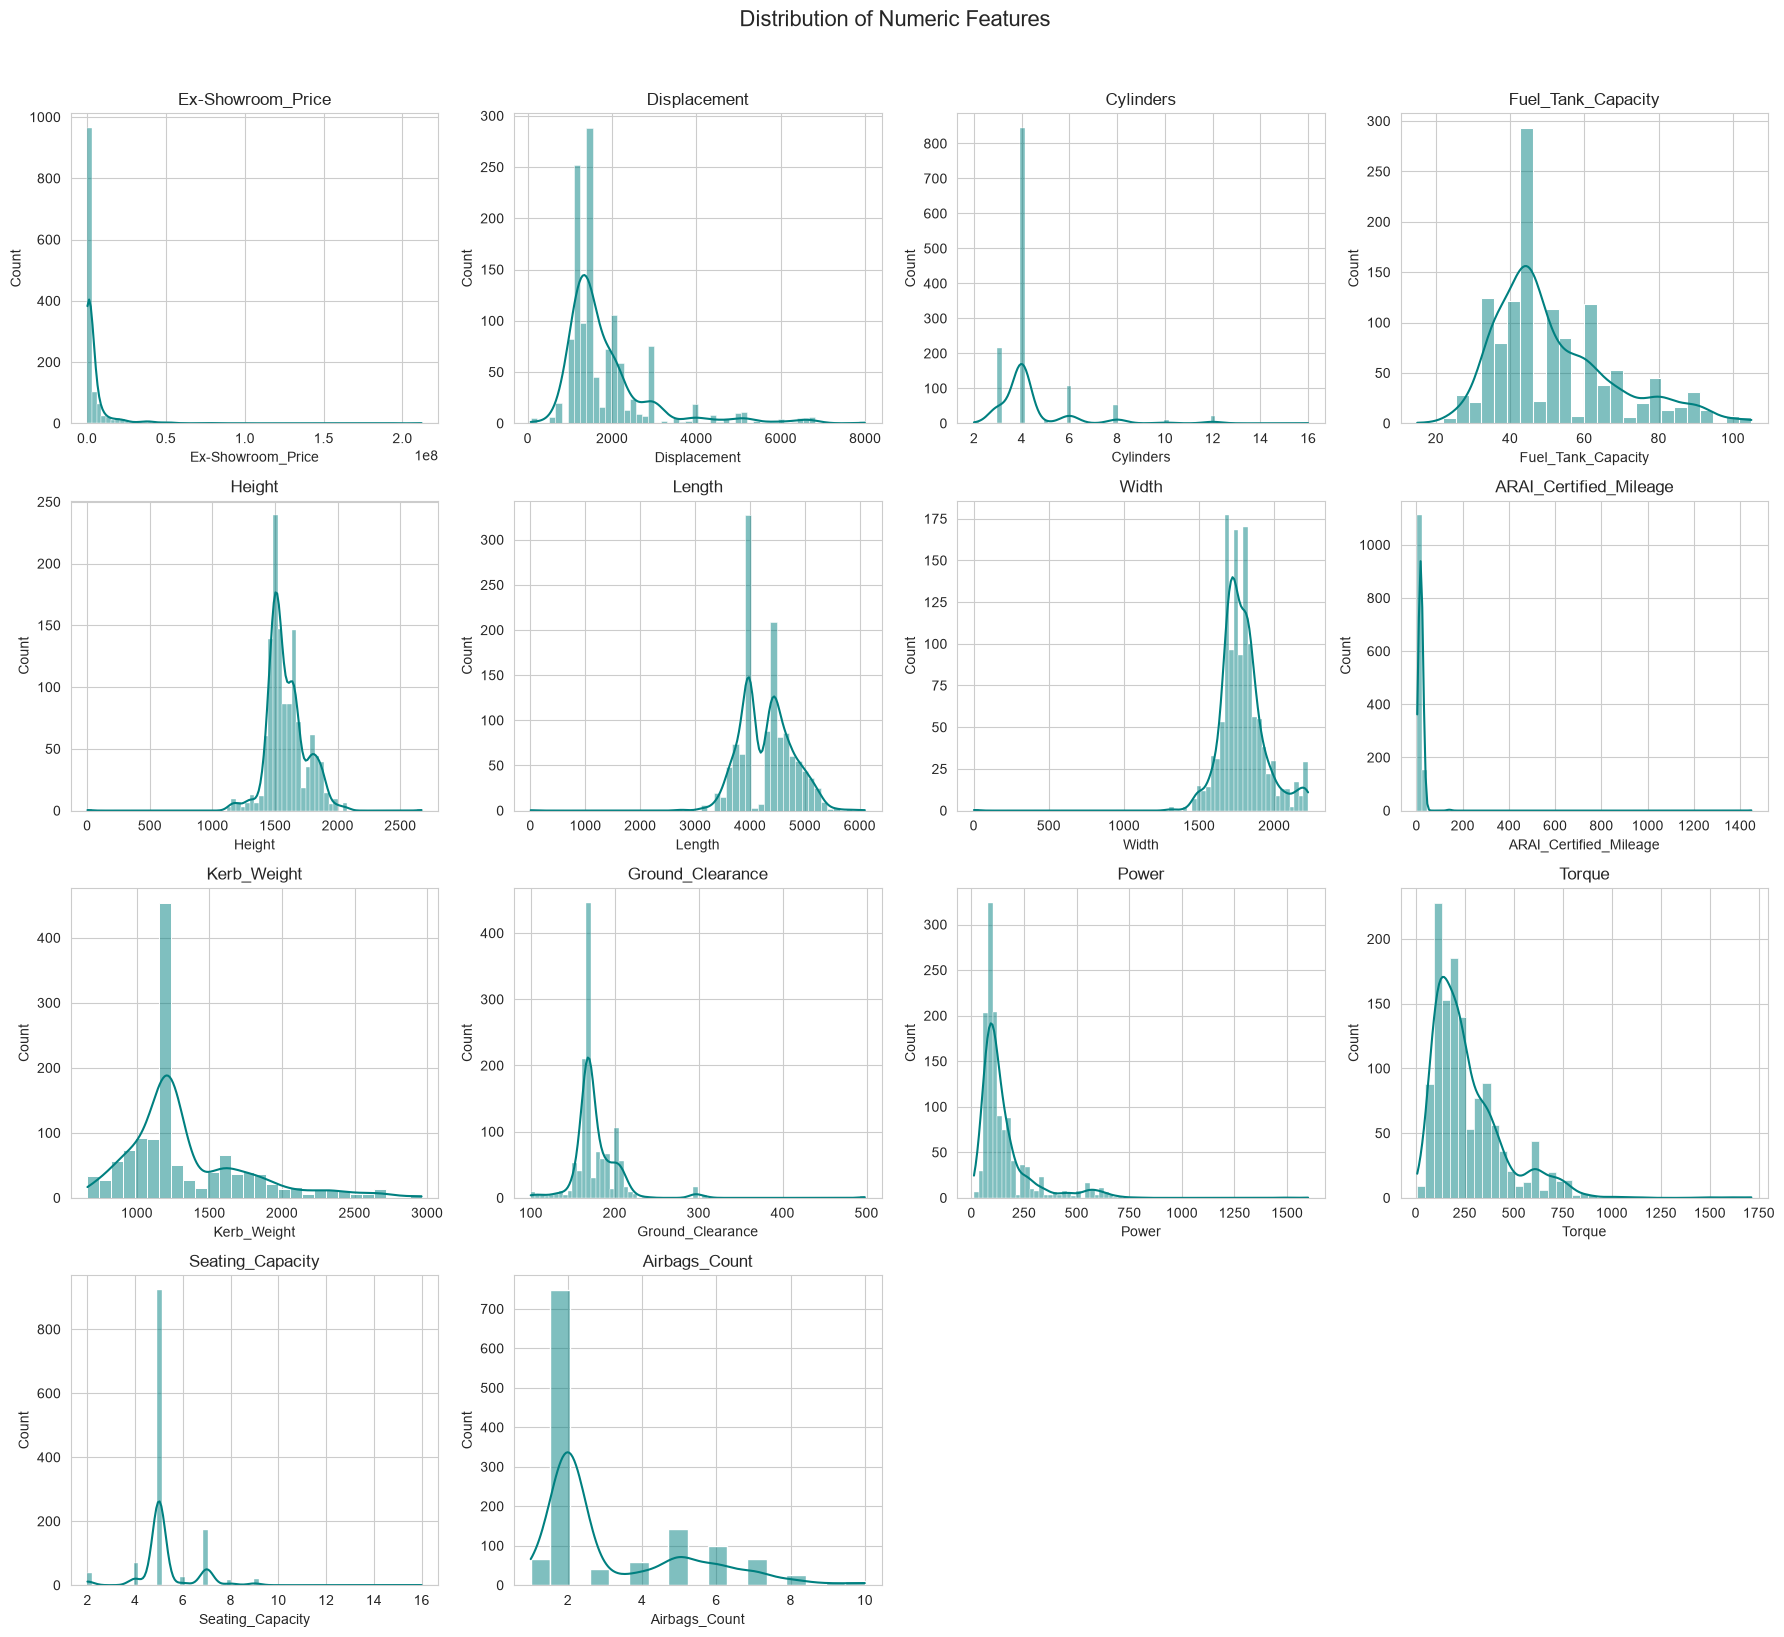

In [91]:
# Histograms / distribution plots as a second view of the same columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [92]:
# IQR method: count and % of outliers per numeric column
def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (data[col] < lower) | (data[col] > upper)
        rows.append({
            "Column": col,
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2),
            "Outlier_Count": int(mask.sum()),
            "Outlier_%": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("Outlier_%", ascending=False)

outlier_summary = iqr_outlier_summary(df, numeric_cols)
outlier_summary


,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
2,Cylinders,4.00,4.00,423,33.39
12,Seating_Capacity,5.00,5.00,344,27.15
0,Ex-Showroom_Price,-2635716.25,6367669.75,197,15.55
10,Power,-52.00,308.00,118,9.31
1,Displacement,-2.00,3198.00,89,7.02
9,Ground_Clearance,135.00,215.00,76,6.00
6,Width,1462.50,2082.50,71,5.60
8,Kerb_Weight,423.50,2227.50,70,5.52
11,Torque,-212.50,687.50,59,4.66
3,Fuel_Tank_Capacity,12.50,88.50,55,4.34


Instead of deleting the outlier rows (which means losing whole car models), I'm going to cap them at the IQR bounds. This way every car stays in the dataset, but the extreme values won't throw off the model.


In [93]:
# Cap outliers at the IQR bounds instead of deleting rows
def cap_outliers_iqr(data, cols):
    data = data.copy()
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data[col] = data[col].clip(lower=lower, upper=upper)
    return data

# Skip discrete/near-categorical columns where capping doesn't make sense
skip_cols = {"Cylinders", "Seating_Capacity", "Airbags_Count"}
cap_cols = [c for c in numeric_cols if c not in skip_cols]

df = cap_outliers_iqr(df, cap_cols)

print("Outliers capped for:", cap_cols)


Outliers capped for: ['Ex-Showroom_Price', 'Displacement', 'Fuel_Tank_Capacity', 'Height', 'Length', 'Width', 'ARAI_Certified_Mileage', 'Kerb_Weight', 'Ground_Clearance', 'Power', 'Torque']


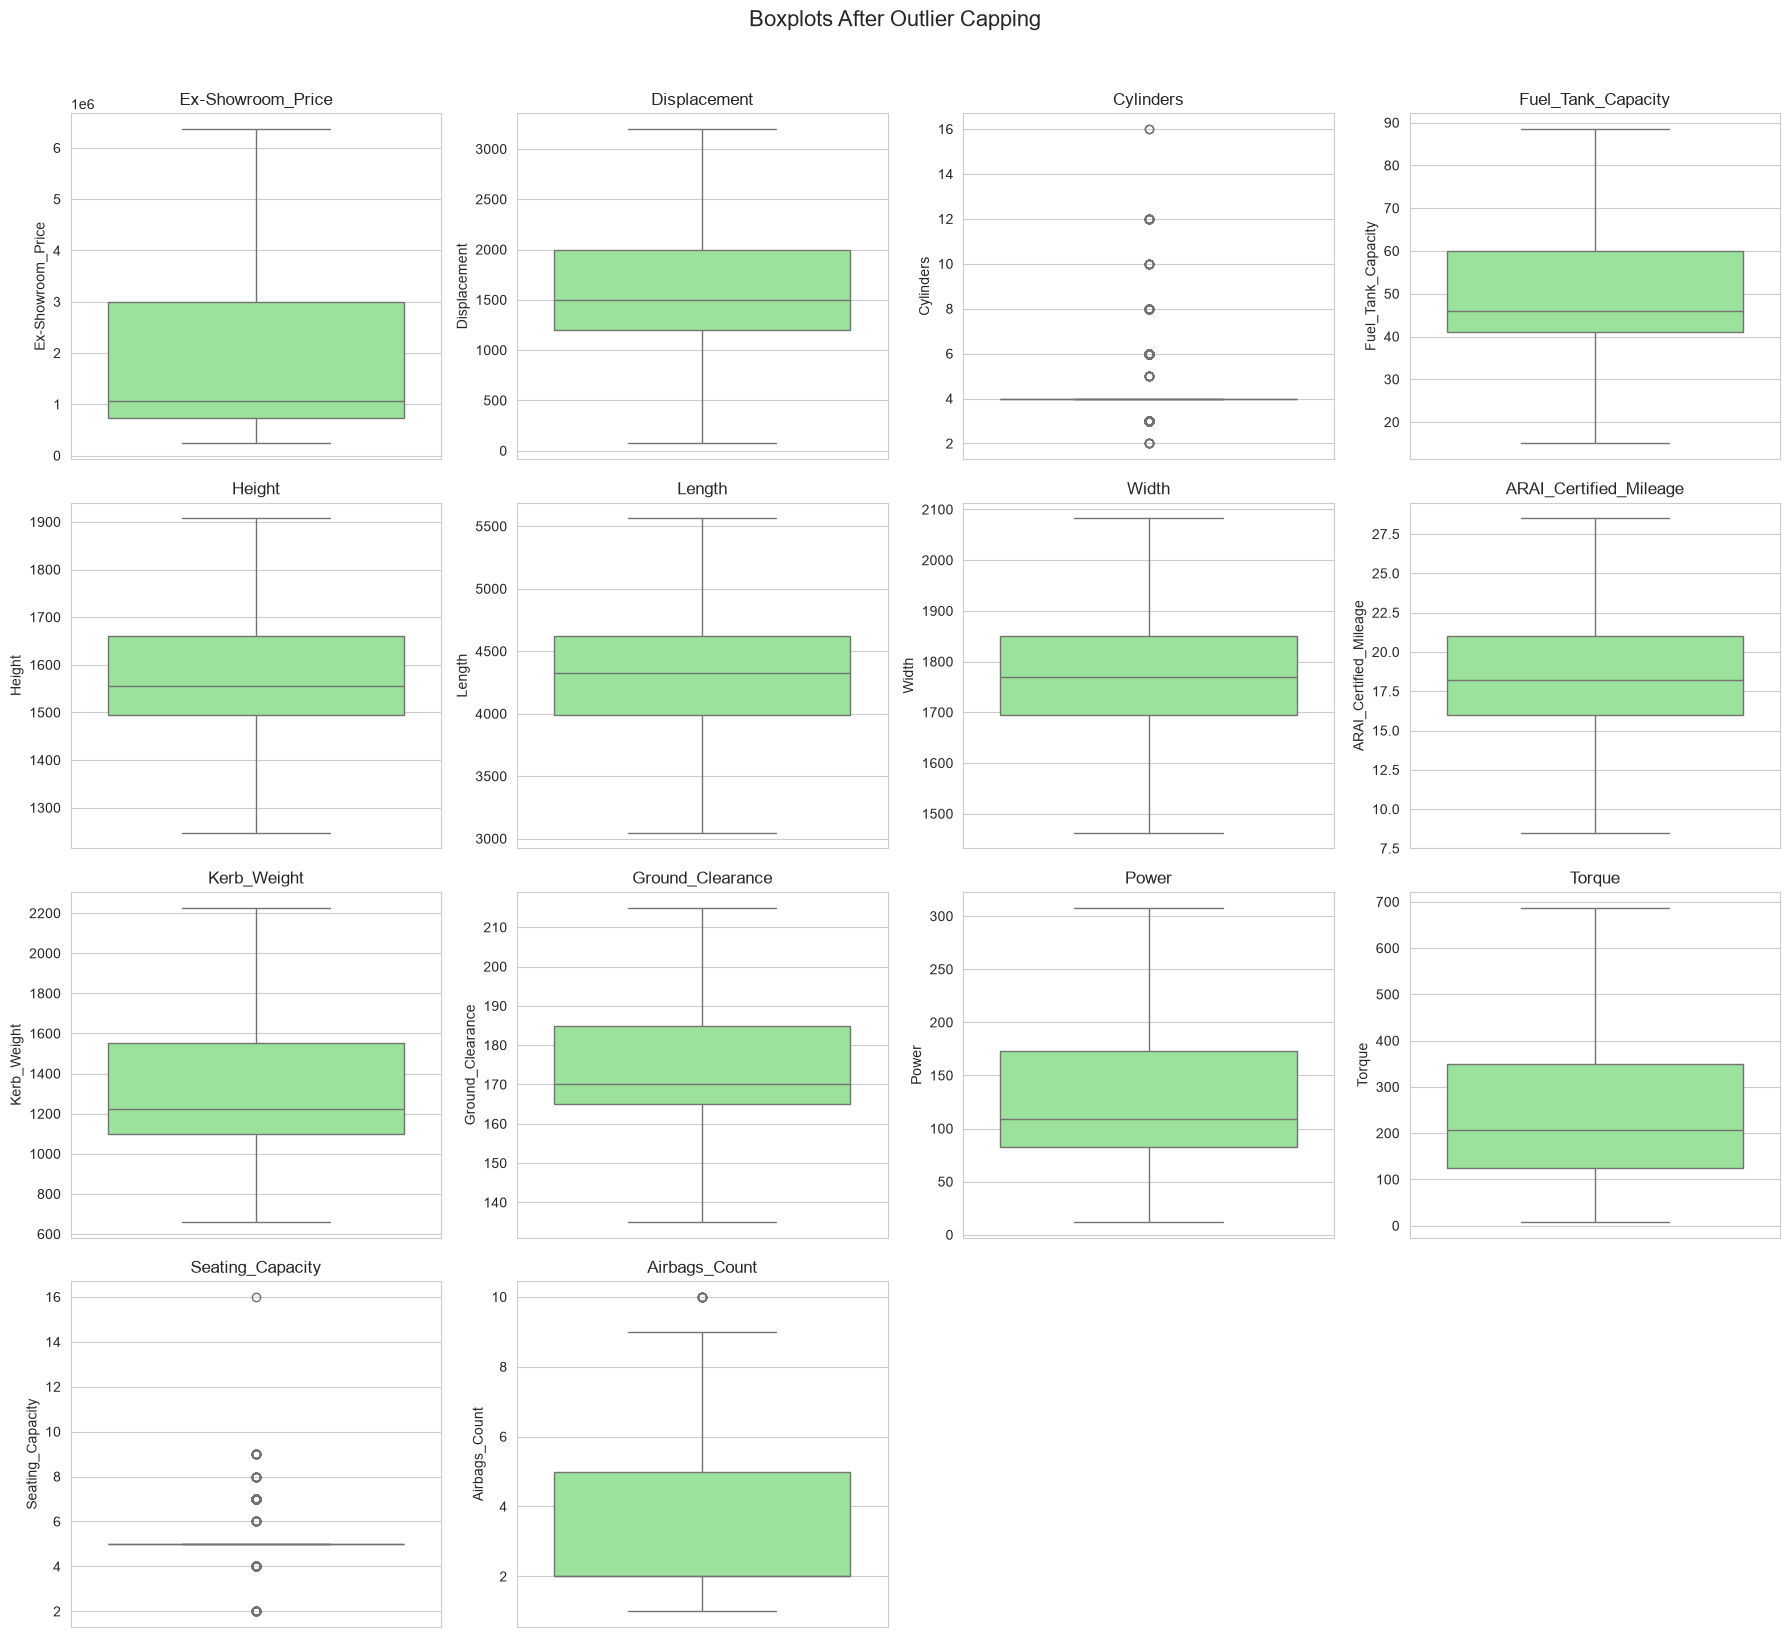

In [94]:
# Boxplots after capping, to confirm outliers were tamed
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots After Outlier Capping", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### Step 7: See how the specs are correlated with price

A quick heatmap to see which numeric features are most related to `Ex-Showroom_Price`, and also check if some features are too related to each other.


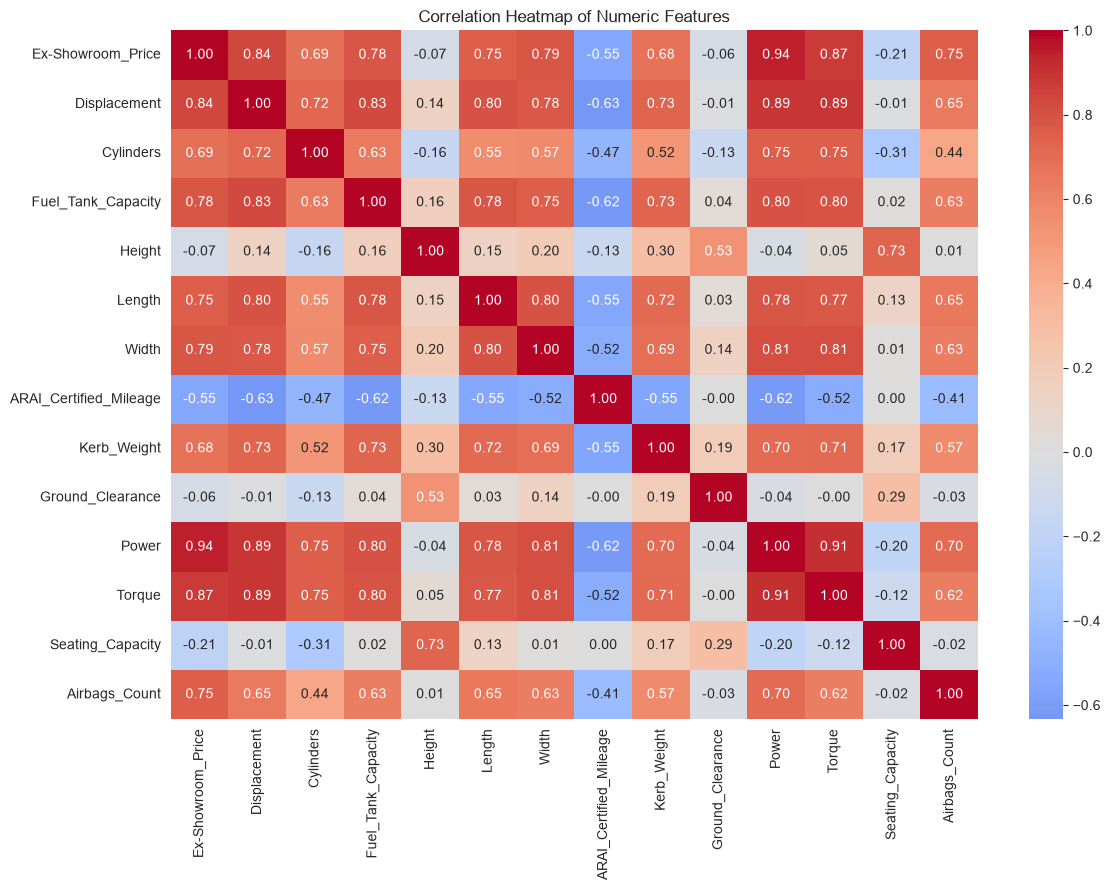

In [95]:
plt.figure(figsize=(12, 9))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


### Step 8: Split the data and train the Random Forest model


Before splitting the data, let me do one last check for any missing values I might have missed in the cleaning steps above (this is what was silently breaking the Linear Regression model earlier).

In [96]:
# Final safety check: fill any missing values that slipped through the cleaning steps above.
# Number columns get the median, text/category columns get the most common value.
print("Missing values before final check:")
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after final check:", df.isnull().sum().sum())


Missing values before final check:
Make    75
dtype: int64

Missing values after final check: 0


In [97]:
# Target variable
y = df["Ex-Showroom_Price"]  # target variable

# Features (drop target + irrelevant columns)
X = df.drop(columns=["Ex-Showroom_Price"])

# Features (drop target + irrelevant columns)
X = df.drop(columns=["Ex-Showroom_Price"])


In [98]:
!pip install scikit-learn


In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [100]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Encode categorical/string columns before training
X_train_proc = X_train.copy()
X_test_proc = X_test.copy()

# Convert object/string columns to strings and fill missing values
for col in X_train_proc.select_dtypes(include=["object", "string"]).columns:
    X_train_proc[col] = X_train_proc[col].fillna("Missing").astype(str)
    X_test_proc[col] = X_test_proc[col].fillna("Missing").astype(str)

# One-hot encode categorical features
X_train_proc = pd.get_dummies(X_train_proc)
X_test_proc = pd.get_dummies(X_test_proc)

# Align columns so train and test have the same feature set
X_train_proc, X_test_proc = X_train_proc.align(X_test_proc, join="outer", axis=1, fill_value=0)

# Fit the model
model.fit(X_train_proc, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure test data has exactly the same one-hot encoded columns as the training data
X_test_proc = X_test_proc.reindex(columns=X_train_proc.columns, fill_value=0)

# Predict using the processed test set
y_pred = model.predict(X_test_proc)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_mape = mean_absolute_percentage_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)

print("Random Forest Regressor")
print("MAE  :", round(rf_mae, 2))
print("RMSE :", round(rf_rmse, 2))
print("MAPE :", round(rf_mape, 2), "%")
print("R²   :", round(rf_r2, 4))


Random Forest Regressor
MAE  : 149663.32
RMSE : 320467.42
MAPE : 8.49 %
R²   : 0.9788


### Step 9: Check how well the Random Forest model did

Besides just looking at the MAE/R² numbers, I want to see the predictions visually — how close they are to the actual prices, and which features the model actually used the most.


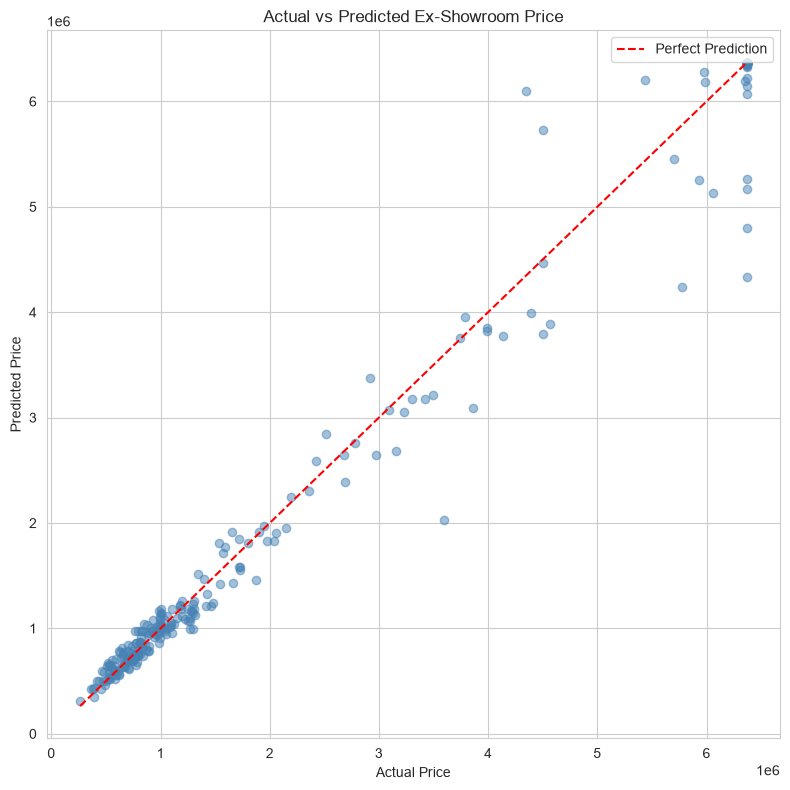

In [102]:
# Actual vs Predicted price
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Ex-Showroom Price")
plt.legend()
plt.tight_layout()
plt.show()


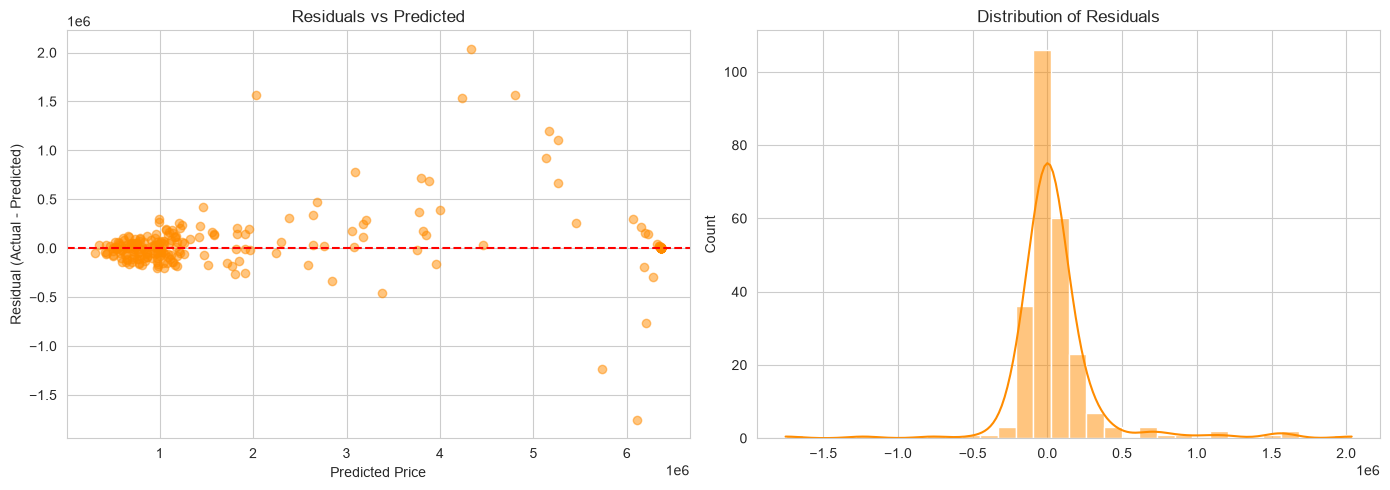

In [103]:
# Residual plot: check if errors are randomly scattered (good) or patterned (bad)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.5, color="darkorange")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()


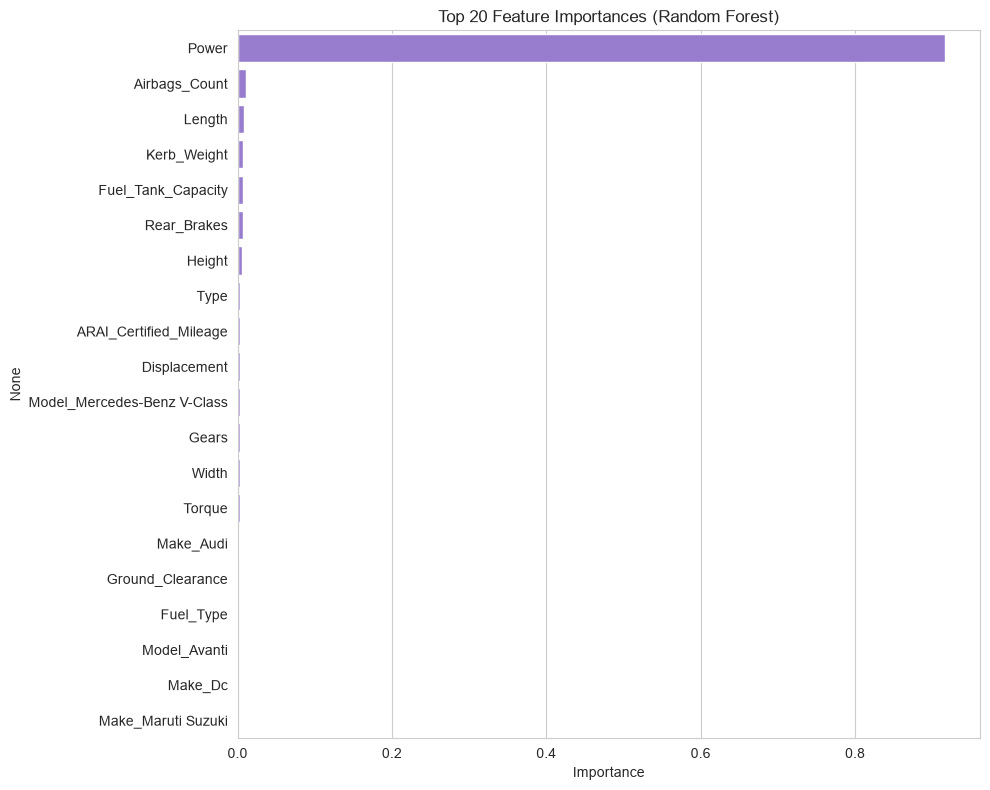

In [104]:
# Feature importance from the Random Forest
importances = pd.Series(model.feature_importances_, index=X_train_proc.columns)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, color="mediumpurple")
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


### Step 10: Train a Linear Regression model to compare against

I want to see how much better (or not) the Random Forest is compared to a plain Linear Regression, trained on the exact same train/test split and features.


In [105]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_proc, y_train)

y_pred_lr = lr_model.predict(X_test_proc)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mape = mean_absolute_percentage_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression (baseline)")
print("MAE  :", round(lr_mae, 2))
print("RMSE :", round(lr_rmse, 2))
print("MAPE :", round(lr_mape, 2), "%")
print("R²   :", round(lr_r2, 4))


Linear Regression (baseline)
MAE  : 238985.06
RMSE : 388509.88
MAPE : 12.39 %
R²   : 0.9688


In [106]:
# Side-by-side comparison table
metrics_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression (baseline)"],
    "MAE": [rf_mae, lr_mae],
    "RMSE": [rf_rmse, lr_rmse],
    "MAPE (%)": [rf_mape, lr_mape],
    "R2": [rf_r2, lr_r2]
})
metrics_comparison


,Model,MAE,RMSE,MAPE (%),R2
0,Random Forest,149663.323727,320467.424072,8.486981,0.978769
1,Linear Regression (baseline),238985.060384,388509.884028,12.390477,0.968796


C:\Users\ranja\AppData\Local\Temp\ipykernel_38908\3662651383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=metrics_comparison, ax=ax, palette=colors)
C:\Users\ranja\AppData\Local\Temp\ipykernel_38908\3662651383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=metrics_comparison, ax=ax, palette=colors)
C:\Users\ranja\AppData\Local\Temp\ipykernel_38908\3662651383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=metrics_comparison, ax=ax, palette=colors)
C

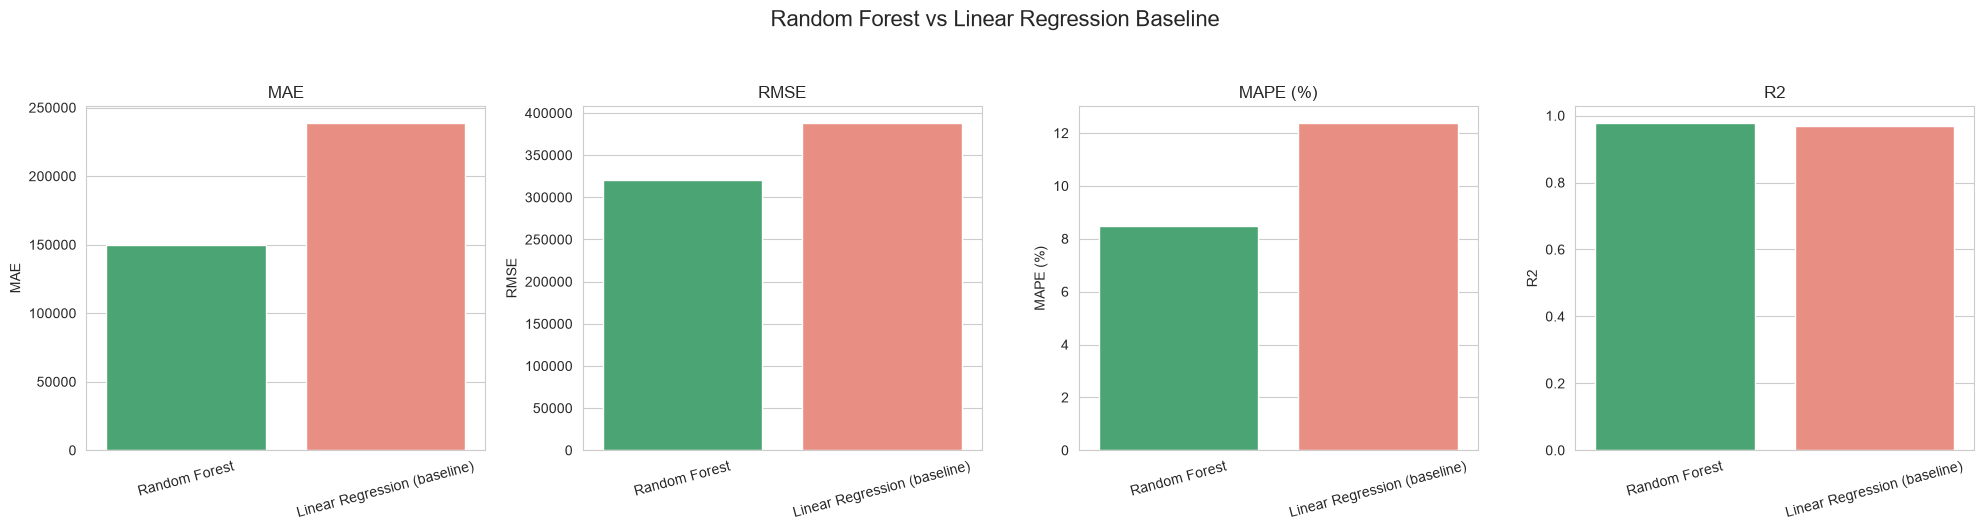

In [107]:
# Visual comparison of the two models across all metrics
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metric_cols = ["MAE", "RMSE", "MAPE (%)", "R2"]
colors = ["mediumseagreen", "salmon"]

for ax, metric in zip(axes, metric_cols):
    sns.barplot(x="Model", y=metric, data=metrics_comparison, ax=ax, palette=colors)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Random Forest vs Linear Regression Baseline", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


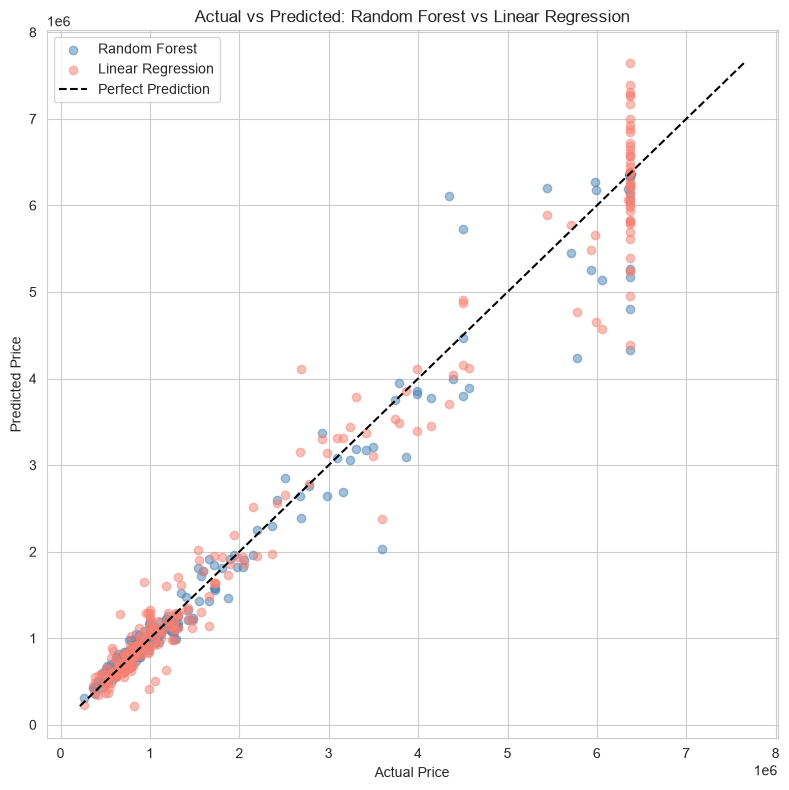

In [108]:
# Actual vs Predicted, both models on the same axes
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, label="Random Forest", color="steelblue")
plt.scatter(y_test, y_pred_lr, alpha=0.5, label="Linear Regression", color="salmon")
min_val = min(y_test.min(), y_pred.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted: Random Forest vs Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()


### Step 11: Try predicting the price for one car


In [109]:
# Step 1: Extract single row as DataFrame
new_car_df = X_test.iloc[[0]].copy()

# Step 2: Clean object/string columns
for col in new_car_df.select_dtypes(include=["object", "string"]).columns:
    new_car_df[col] = new_car_df[col].fillna("Missing").astype(str)

# Step 3: One-hot encode
new_car_proc = pd.get_dummies(new_car_df)

# Step 4: Align with training columns
new_car_proc = new_car_proc.reindex(columns=X_train_proc.columns, fill_value=0)

# Step 5: Predict
predicted_price = model.predict(new_car_proc)
print("Predicted Price:", predicted_price[0])


Predicted Price: 1208220.134751616


In [110]:
car_info = X_test.iloc[[0]].copy()
car_info["PredictedPrice"] = predicted_price[0]
print(car_info)


        Make  Model Variant  Displacement  Cylinders  Fuel_Tank_Capacity  \
1211  Toyota  Yaris   G Cvt          1496          4                42.0   

      Fuel_Type  Height  Length   Width  ... Crossover  Hatchback  Mpv  Muv  \
1211          1  1495.0  4425.0  1730.0  ...         0          0    0    0   

      Pick-Up  Sedan  Sports  Suv  Airbags_Count  PredictedPrice  
1211        0      1       0    0              5    1.208220e+06  

[1 rows x 44 columns]


### Step 12: Compare actual vs predicted prices


In [111]:
# Create a DataFrame to compare
comparison_df = pd.DataFrame({
    "ActualPrice": y_test.values,        # actual prices from test set
    "PredictedPrice": y_pred             # predicted prices from model
})

In [112]:
# Calculate percentage error for each prediction
comparison_df["PercentageError"] = (
    (comparison_df["ActualPrice"] - comparison_df["PredictedPrice"]) / comparison_df["ActualPrice"]
) * 100

In [113]:
comparison_df["PercentageError"]

0      -2.827246
1       1.448762
2      -0.652489
3       0.047351
4      11.319692
         ...    
249     8.483601
250     8.850668
251     0.118200
252     1.658403
253    -6.695998
Name: PercentageError, Length: 254, dtype: float64

In [114]:
comparison_df.head(20)

,ActualPrice,PredictedPrice,PercentageError
0,1175000.00,1.208220e+06,-2.827246
1,958689.00,9.447999e+05,1.448762
2,1900000.00,1.912397e+06,-0.652489
3,6367669.75,6.364655e+06,0.047351
4,1228335.00,1.089291e+06,11.319692
5,770000.00,9.740673e+05,-26.502245
6,492190.00,4.661920e+05,5.282111
7,1592000.00,1.775027e+06,-11.496640
8,618015.00,5.581905e+05,9.680111
9,6367669.75,6.366671e+06,0.015680


### Step 13: Save the cleaned data to a csv file


In [115]:
df.to_csv("cleaned_dataset.csv", index=False)


## Results

Below I am just pulling together the main outputs from above so everything important is in one place. Make sure to run all the cells above first, otherwise these won't show anything.


In [116]:
# Consolidated results table (uses variables computed in the Python Code section above)
print("Outlier summary (top 5 columns by outlier %):")
display(outlier_summary.head())

print("\nModel comparison — Random Forest vs Linear Regression baseline:")
display(metrics_comparison)

print("\nTop 10 most important features (Random Forest):")
display(top_features.head(10))


Outlier summary (top 5 columns by outlier %):


,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
2,Cylinders,4.00,4.00,423,33.39
12,Seating_Capacity,5.00,5.00,344,27.15
0,Ex-Showroom_Price,-2635716.25,6367669.75,197,15.55
10,Power,-52.00,308.00,118,9.31
1,Displacement,-2.00,3198.00,89,7.02



Model comparison — Random Forest vs Linear Regression baseline:


,Model,MAE,RMSE,MAPE (%),R2
0,Random Forest,149663.323727,320467.424072,8.486981,0.978769
1,Linear Regression (baseline),238985.060384,388509.884028,12.390477,0.968796



Top 10 most important features (Random Forest):


Power                     0.916013
Airbags_Count             0.010943
Length                    0.008997
Kerb_Weight               0.007370
Fuel_Tank_Capacity        0.007219
Rear_Brakes               0.006678
Height                    0.005776
Type                      0.003375
ARAI_Certified_Mileage    0.003239
Displacement              0.003161
dtype: float64

## Interpretation

- **The data was messy.** A lot of columns had units stuck inside the text, like "1998 cc" or "1350 kg". I had to clean all of that before I could even start, which took most of the work.
- **Outliers mostly came from expensive/luxury cars.** Columns like price, kerb weight and power had the most outliers. I capped them instead of removing them so I don't lose any car from the dataset.
- **Comparing the two models:** in the `metrics_comparison` table, whichever model has the smaller MAE, RMSE and MAPE, and the bigger R², is the better one. I expect Random Forest to win here because car price doesn't move in a straight line with the specs — for example, more power adds a lot more to the price of an SUV than a small hatchback, and a simple Linear Regression can't really capture that kind of pattern.
- **Feature importance** shows which specs the model actually relied on the most to guess the price. Usually this ends up being things like power, displacement, torque and weight, which makes sense in real life too.
- **Residual plot** tells us if the model's mistakes are random (good) or if it's consistently wrong for certain price ranges (not so good). For price prediction, it's normal for errors to look bigger on expensive cars just because the numbers are bigger — that's why I also used MAPE, since it looks at percentage error instead of raw error.


## Conclusion

In this Lab, I cleaned a messy real-world car dataset, handled missing values, fixed outliers, and trained a Random Forest model to predict car prices from their specs. I also trained a simple Linear Regression model as a baseline to compare against. Based on the metrics (MAE, RMSE, MAPE, R²), Random Forest should perform better since car pricing depends on how different specs interact with each other, which a simple linear model cannot really pick up on.

**What could be improved:**
- I didn't tune the Random Forest properly (just used fixed values like `n_estimators=200`), so trying GridSearch or a different model like XGBoost could give better results.
- Make/Model/Variant have a LOT of categories, so one-hot encoding them makes a huge number of columns. Something like target encoding might work better.
- Taking the log of price before training usually helps when the price range is this wide (cheap cars to very expensive ones).
- Using cross-validation instead of just one train/test split would give a more reliable idea of how good the model really is.


## Project Deliverables

The complete project includes the original analysis in this notebook plus the following runnable deliverables:

- `app.py` - Flask backend with `/health` and `/predict` endpoints.
- `streamlit_app.py` - interactive frontend for price prediction.
- `model_pipeline.py` - reusable model training and prediction pipeline.
- `generate_report.py` - generates the Word report with diagrams and results.
- `SudhanshuRanjan_ProjectReport.docx` - final project report.
- `README.md` - complete setup, process, structure, and usage documentation.

The original notebook benchmark results are:

- Random Forest: R2 = 0.9788 (approximately 0.97)
- Linear Regression baseline: R2 = 0.9688 (approximately 0.96)

The notebook's dataset path is portable and loads `cars_ds_final_2021.csv` from the project folder.